In [60]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [61]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [62]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
display(df.sample(5))

(100, 6)


,col1,col2,col3,col4,col5,target
63,-0.234661,-0.712666,-1.342085,-0.681593,1.342218,0
72,3.167985,-0.409923,-1.440143,-2.092682,0.030884,1
76,0.128706,-0.096796,-0.151501,-3.253646,1.913434,0
51,4.939962,-0.677819,-0.982499,-2.113909,0.490142,1
43,1.760042,-1.396907,-0.507852,0.515775,-2.711982,1


In [63]:
# function for row sampling

def sample_row(df,percent):
    return df.sample(int(percent*df.shape[0]))

In [64]:
# function for feature sampling

def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [65]:
# function for combine sampling

def combine_sampling(df,row_percent,col_percent):
    new_df = sample_row(df,row_percent)
    return sample_features(new_df, col_percent)

# RandomForest With Row Sampling

In [66]:
df1 = sample_row(df,0.2)
df2 = sample_row(df,0.2)
df3 = sample_row(df,0.2)

In [67]:
clf1 = DecisionTreeClassifier().fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2 = DecisionTreeClassifier().fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3 = DecisionTreeClassifier().fit(df3.iloc[:,0:5],df3.iloc[:,-1])

In [70]:
# lets predict this [1.298981, 1.525866, -2.254752, 3.611956, 1.529172] -> [0]

print(clf1.predict(np.array([0.128706, -0.096796, -0.151501, -3.253646, 1.913434]).reshape(1,5)))
print(clf2.predict(np.array([0.128706, -0.096796, -0.151501, -3.253646, 1.913434]).reshape(1,5)))
print(clf3.predict(np.array([0.128706, -0.096796, -0.151501, -3.253646, 1.913434]).reshape(1,5)))

[0]
[0]
[1]


C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[Text(0.5, 0.8333333333333334, 'x[4] <= -0.029\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.25, 0.5, 'x[0] <= 1.198\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.5, 'x[2] <= -1.949\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

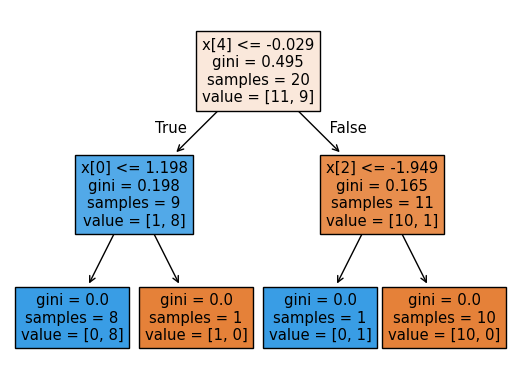

In [71]:
# ploting decision tree)
plot_tree(clf1, filled=True)

[Text(0.5555555555555556, 0.9, 'x[4] <= 1.268\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.4444444444444444, 0.7, 'x[0] <= 0.377\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.5, 0.8, 'True  '),
 Text(0.2222222222222222, 0.5, 'x[2] <= -1.332\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.5, 'x[4] <= 1.105\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.5555555555555556, 0.3, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.7777777777777778, 0.3, 'x[1] <= 0.638\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8888888888888888, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.7, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.6111111111111112, 0.8, '  False')]

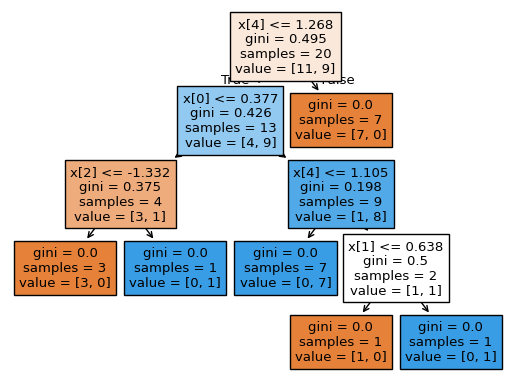

In [72]:
plot_tree(clf2, filled=True)

[Text(0.2857142857142857, 0.9166666666666666, 'x[4] <= -0.484\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.14285714285714285, 0.75, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.21428571428571427, 0.8333333333333333, 'True  '),
 Text(0.42857142857142855, 0.75, 'x[2] <= -2.226\ngini = 0.473\nsamples = 13\nvalue = [8, 5]'),
 Text(0.3571428571428571, 0.8333333333333333, '  False'),
 Text(0.2857142857142857, 0.5833333333333334, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5714285714285714, 0.5833333333333334, 'x[3] <= -3.226\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7142857142857143, 0.4166666666666667, 'x[4] <= 0.004\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.5714285714285714, 0.25, 'x[0] <= 1.306\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.42857142857142855, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.714285714285714

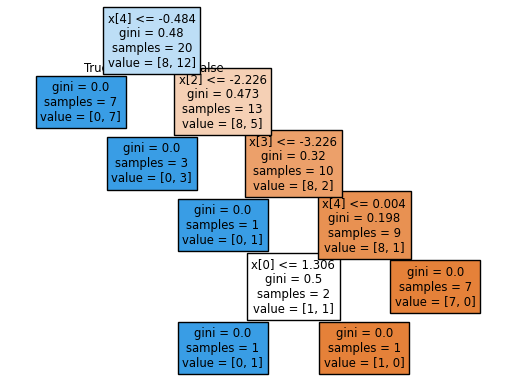

In [73]:
plot_tree(clf3, filled=True)

# RandomForest With Column Sampling

In [79]:
sample_features(df,0.8)

C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,col1,col3,col5,target
0,-1.045239,0.139132,-2.412089,-0.651787,0
1,2.180894,0.177667,-1.009197,-3.914241,1
2,2.212124,1.298464,-0.194220,1.994353,0
3,-2.530153,1.668781,-1.158532,0.840014,0
4,0.364043,1.323249,-2.767223,-0.877493,0
...,...,...,...,...,...
95,-2.744911,0.089599,-0.769533,2.519252,0
96,0.156000,2.503105,0.703065,0.765501,0
97,-0.538547,-0.484513,-0.881893,0.930523,0
98,1.773732,4.097551,-0.626271,-3.744214,1


In [99]:
df1 = sample_features(df,0.8)
df2 = sample_features(df,0.8)
df3 = sample_features(df,0.8)

C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [100]:
clf1 = DecisionTreeClassifier().fit(df1.iloc[:,0:4], df1.iloc[:,-1])
clf2 = DecisionTreeClassifier().fit(df1.iloc[:,0:4], df2.iloc[:,-1])
clf3 = DecisionTreeClassifier().fit(df1.iloc[:,0:4], df3.iloc[:,-1])

In [101]:
# lets predict this [2.180894, 0.177667, -1.009197, -3.914241] -> [1]

print(clf1.predict(np.array([2.180894, 0.177667, -1.009197, -3.914241]).reshape(1,4)))
print(clf2.predict(np.array([2.180894, 0.177667, -1.009197, -3.914241]).reshape(1,4)))
print(clf3.predict(np.array([2.180894, 0.177667, -1.009197, -3.914241]).reshape(1,4)))

[1]
[1]
[1]


C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[Text(0.4230769230769231, 0.95, 'x[3] <= -0.902\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.85, 'x[3] <= -1.585\ngini = 0.062\nsamples = 31\nvalue = [1, 30]'),
 Text(0.28846153846153844, 0.8999999999999999, 'True  '),
 Text(0.07692307692307693, 0.75, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.23076923076923078, 0.75, 'x[3] <= -1.507\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.15384615384615385, 0.65, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.65, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.6923076923076923, 0.85, 'x[1] <= -1.093\ngini = 0.412\nsamples = 69\nvalue = [49, 20]'),
 Text(0.5576923076923077, 0.8999999999999999, '  False'),
 Text(0.5384615384615384, 0.75, 'x[2] <= 2.885\ngini = 0.492\nsamples = 39\nvalue = [22, 17]'),
 Text(0.46153846153846156, 0.65, 'x[1] <= -1.307\ngini = 0.457\nsamples = 34\nvalue = [22, 12]'),
 Text(0.38461538461538464, 0.55, 'x[0] <= -1.574\ngini = 0.391\nsamples =

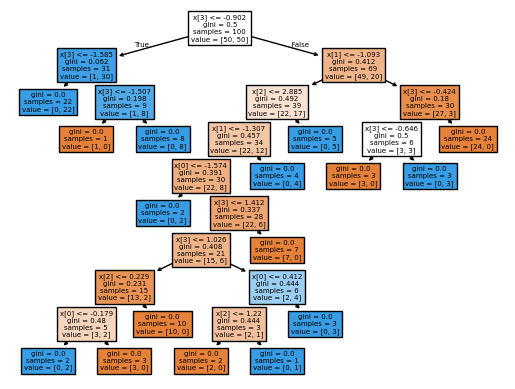

In [85]:
# ploting decision tree
plot_tree(clf1, filled=True)

[Text(0.4230769230769231, 0.95, 'x[3] <= -0.902\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.85, 'x[3] <= -1.585\ngini = 0.062\nsamples = 31\nvalue = [1, 30]'),
 Text(0.28846153846153844, 0.8999999999999999, 'True  '),
 Text(0.07692307692307693, 0.75, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.23076923076923078, 0.75, 'x[3] <= -1.507\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.15384615384615385, 0.65, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.65, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.6923076923076923, 0.85, 'x[1] <= -1.093\ngini = 0.412\nsamples = 69\nvalue = [49, 20]'),
 Text(0.5576923076923077, 0.8999999999999999, '  False'),
 Text(0.5384615384615384, 0.75, 'x[2] <= 2.885\ngini = 0.492\nsamples = 39\nvalue = [22, 17]'),
 Text(0.46153846153846156, 0.65, 'x[1] <= -1.307\ngini = 0.457\nsamples = 34\nvalue = [22, 12]'),
 Text(0.38461538461538464, 0.55, 'x[0] <= -1.574\ngini = 0.391\nsamples =

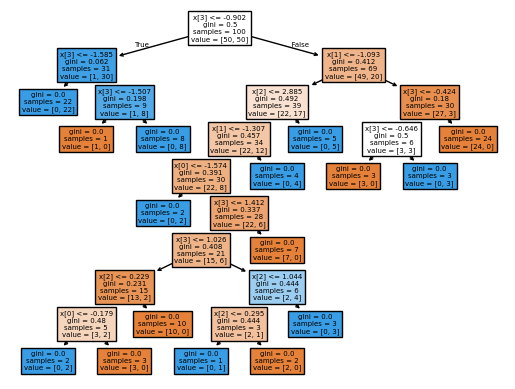

In [86]:
plot_tree(clf2, filled=True)

[Text(0.4230769230769231, 0.95, 'x[3] <= -0.902\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.85, 'x[3] <= -1.585\ngini = 0.062\nsamples = 31\nvalue = [1, 30]'),
 Text(0.28846153846153844, 0.8999999999999999, 'True  '),
 Text(0.07692307692307693, 0.75, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.23076923076923078, 0.75, 'x[3] <= -1.507\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.15384615384615385, 0.65, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.65, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.6923076923076923, 0.85, 'x[1] <= -1.093\ngini = 0.412\nsamples = 69\nvalue = [49, 20]'),
 Text(0.5576923076923077, 0.8999999999999999, '  False'),
 Text(0.5384615384615384, 0.75, 'x[2] <= 2.885\ngini = 0.492\nsamples = 39\nvalue = [22, 17]'),
 Text(0.46153846153846156, 0.65, 'x[1] <= -1.307\ngini = 0.457\nsamples = 34\nvalue = [22, 12]'),
 Text(0.38461538461538464, 0.55, 'x[0] <= -1.574\ngini = 0.391\nsamples =

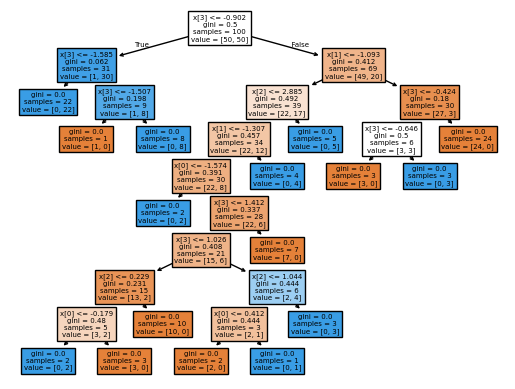

In [87]:
plot_tree(clf3, filled=True)

# RandomForest With Combine Sampling

In [91]:
combine_sampling(df,0.4,0.8)

C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col1,col5,col3,col4,target
35,1.214741,-0.898128,-2.050098,-1.401451,0
57,2.474118,-1.756231,-0.673838,-0.471836,1
29,-2.273034,1.651318,-0.977760,-3.934508,0
17,0.726466,0.443254,-1.237151,-0.012278,0
39,-0.984901,-1.656239,-3.351971,1.900959,1
24,1.071916,-0.246138,-0.606229,-1.207487,1
98,4.097551,-3.744214,-0.626271,1.773732,1
48,1.747483,0.229728,-1.060523,0.134578,0
33,-0.064566,-1.975950,-0.775886,-0.044866,1
44,1.121558,1.231576,-2.381631,-2.501964,1


In [102]:
df1 = combine_sampling(df,0.4,0.8)
df2 = combine_sampling(df,0.4,0.8)
df3 = combine_sampling(df,0.4,0.8)

C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\prabh\AppData\Local\Temp\ipykernel_12688\1158166936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [103]:
clf1 = DecisionTreeClassifier().fit(df1.iloc[:,0:4], df1.iloc[:,-1])
clf2 = DecisionTreeClassifier().fit(df2.iloc[:,0:4], df2.iloc[:,-1])
clf3 = DecisionTreeClassifier().fit(df3.iloc[:,0:4], df3.iloc[:,-1])

In [108]:
# lets predict this [1.835327, 2.516806, -0.946829, -0.798780]-> [1]

print(clf1.predict(np.array([1.835327, 2.516806, -0.946829, -0.798780]).reshape(1,4)))
print(clf2.predict(np.array([1.835327, 2.516806, -0.946829, -0.798780]).reshape(1,4)))
print(clf3.predict(np.array([1.835327, 2.516806, -0.946829, -0.798780]).reshape(1,4)))

[0]
[1]
[1]


C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[Text(0.4444444444444444, 0.9285714285714286, 'x[3] <= -1.585\ngini = 0.469\nsamples = 40\nvalue = [25, 15]'),
 Text(0.3333333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.38888888888888884, 0.8571428571428572, 'True  '),
 Text(0.5555555555555556, 0.7857142857142857, 'x[2] <= 0.561\ngini = 0.408\nsamples = 35\nvalue = [25, 10]'),
 Text(0.5, 0.8571428571428572, '  False'),
 Text(0.3333333333333333, 0.6428571428571429, 'x[0] <= -1.093\ngini = 0.252\nsamples = 27\nvalue = [23, 4]'),
 Text(0.2222222222222222, 0.5, 'x[0] <= -2.322\ngini = 0.408\nsamples = 14\nvalue = [10, 4]'),
 Text(0.1111111111111111, 0.35714285714285715, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.3333333333333333, 0.35714285714285715, 'x[0] <= -1.908\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.2222222222222222, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4444444444444444, 0.21428571428571427, 'x[1] <= -0.484\ngini = 0.32\nsamples = 5\nvalu

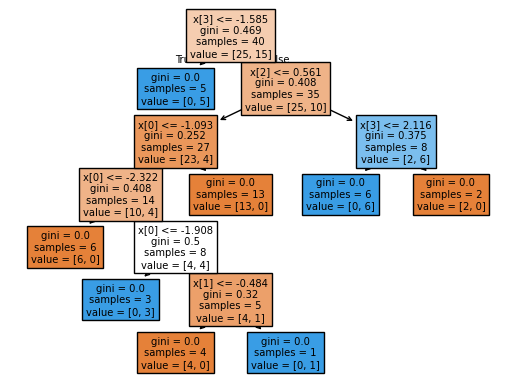

In [110]:
# ploting the tree

plot_tree(clf1, filled=True)

[Text(0.5, 0.9166666666666666, 'x[2] <= 0.212\ngini = 0.495\nsamples = 40\nvalue = [18, 22]'),
 Text(0.3076923076923077, 0.75, 'x[1] <= -2.014\ngini = 0.308\nsamples = 21\nvalue = [4, 17]'),
 Text(0.40384615384615385, 0.8333333333333333, 'True  '),
 Text(0.23076923076923078, 0.5833333333333334, 'x[3] <= 0.469\ngini = 0.494\nsamples = 9\nvalue = [4, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[0] <= 0.513\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.23076923076923078, 0.25, 'x[0] <= 0.925\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.15384615384615385, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3076923076923077, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.4166666666666667, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.38461538461538464, 0.5833333333333334, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 

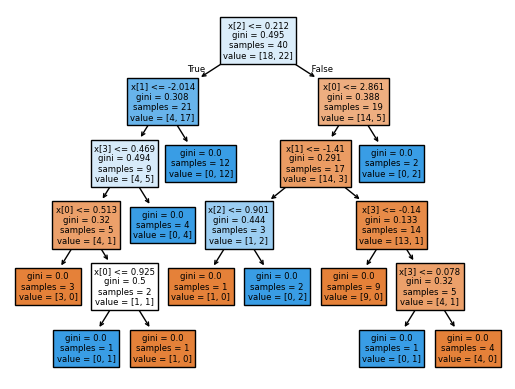

In [111]:
plot_tree(clf2, filled=True)

[Text(0.38461538461538464, 0.9285714285714286, 'x[2] <= -2.853\ngini = 0.499\nsamples = 40\nvalue = [21, 19]'),
 Text(0.3076923076923077, 0.7857142857142857, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.34615384615384615, 0.8571428571428572, 'True  '),
 Text(0.46153846153846156, 0.7857142857142857, 'x[3] <= -1.668\ngini = 0.486\nsamples = 36\nvalue = [21, 15]'),
 Text(0.42307692307692313, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[2] <= -2.126\ngini = 0.48\nsamples = 15\nvalue = [6, 9]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.23076923076923078, 0.5, 'x[2] <= -0.989\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.15384615384615385, 0.35714285714285715, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3076923076923077, 0.35714285714285715, 'x[1] <= -1.574\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.23076923076923078, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')

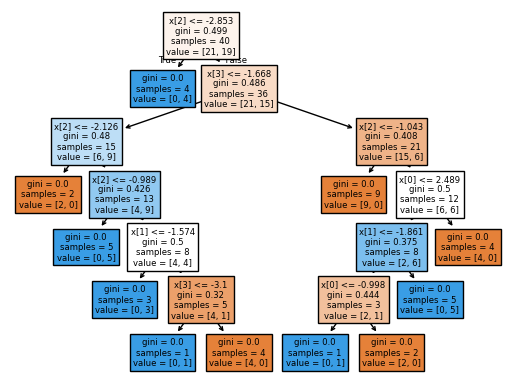

In [112]:
plot_tree(clf3, filled=True)